###Priyank Arora- 2024aa05987
###K ROMA PAI- 2024aa05965
###SHIVAM DWIVEDI- 2024aa05951

#Task 0: Environment Setup & Data Upload

In [14]:
# Installing required libraries
!pip install librosa soundfile pydub nltk hmmlearn scikit-learn matplotlib numpy scipy

# Import all necessary libraries
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.io import wavfile
from sklearn.mixture import GaussianMixture
from hmmlearn import hmm
import os
from google.colab import files
import zipfile
import warnings
warnings.filterwarnings('ignore')

print("All libraries installed successfully!")
print("\n" + "="*60)
print("UPLOAD YOUR AUDIO DATA")
print("="*60)
print("Please upload:")
print("1. Audio files (.wav, .flac format)")
print("2. OR a zip file containing audio files")
print("3. OR transcription text file (optional)")
print("="*60)

# Upload files
uploaded = files.upload()

# Process uploaded files
audio_files = []
text_files = []

for filename in uploaded.keys():
    if filename.endswith('.zip'):
        print(f"\nExtracting {filename}...")
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('audio_data')
        # Find audio files in extracted folder
        for root, dirs, files_list in os.walk('audio_data'):
            for file in files_list:
                if file.endswith(('.wav', '.flac', '.mp3')):
                    audio_files.append(os.path.join(root, file))
    elif filename.endswith(('.wav', '.flac', '.mp3')):
        audio_files.append(filename)
    elif filename.endswith('.txt'):
        text_files.append(filename)

print(f"\nFound {len(audio_files)} audio file(s)")
print(f" Found {len(text_files)} text file(s)")

if audio_files:
    print("\n Audio files loaded:")
    for i, f in enumerate(audio_files[:5], 1):
        print(f"  {i}. {f}")
    if len(audio_files) > 5:
        print(f"  ... and {len(audio_files) - 5} more")
else:
    print("No audio files found. Please upload .wav or .flac files.")

# Store for later use
AUDIO_FILES = audio_files
TEXT_FILES = text_files

All libraries installed successfully!

UPLOAD YOUR AUDIO DATA
Please upload:
1. Audio files (.wav, .flac format)
2. OR a zip file containing audio files
3. OR transcription text file (optional)


Saving dev-clean.zip to dev-clean.zip

Extracting dev-clean.zip...

Found 2720 audio file(s)
 Found 0 text file(s)

 Audio files loaded:
  1. audio_data/dev-clean/2035/147960/2035-147960-0005.flac
  2. audio_data/dev-clean/2035/147960/2035-147960-0010.flac
  3. audio_data/dev-clean/2035/147960/2035-147960-0016.flac
  4. audio_data/dev-clean/2035/147960/2035-147960-0013.flac
  5. audio_data/dev-clean/2035/147960/2035-147960-0011.flac
  ... and 2715 more


#Task 1: Speech Data Loading and Visualization

 Loading audio: 2035-147960-0005.flac
Audio loaded successfully!
   Duration: 6.58 seconds
   Sampling Rate: 16000 Hz
   Samples: 105360


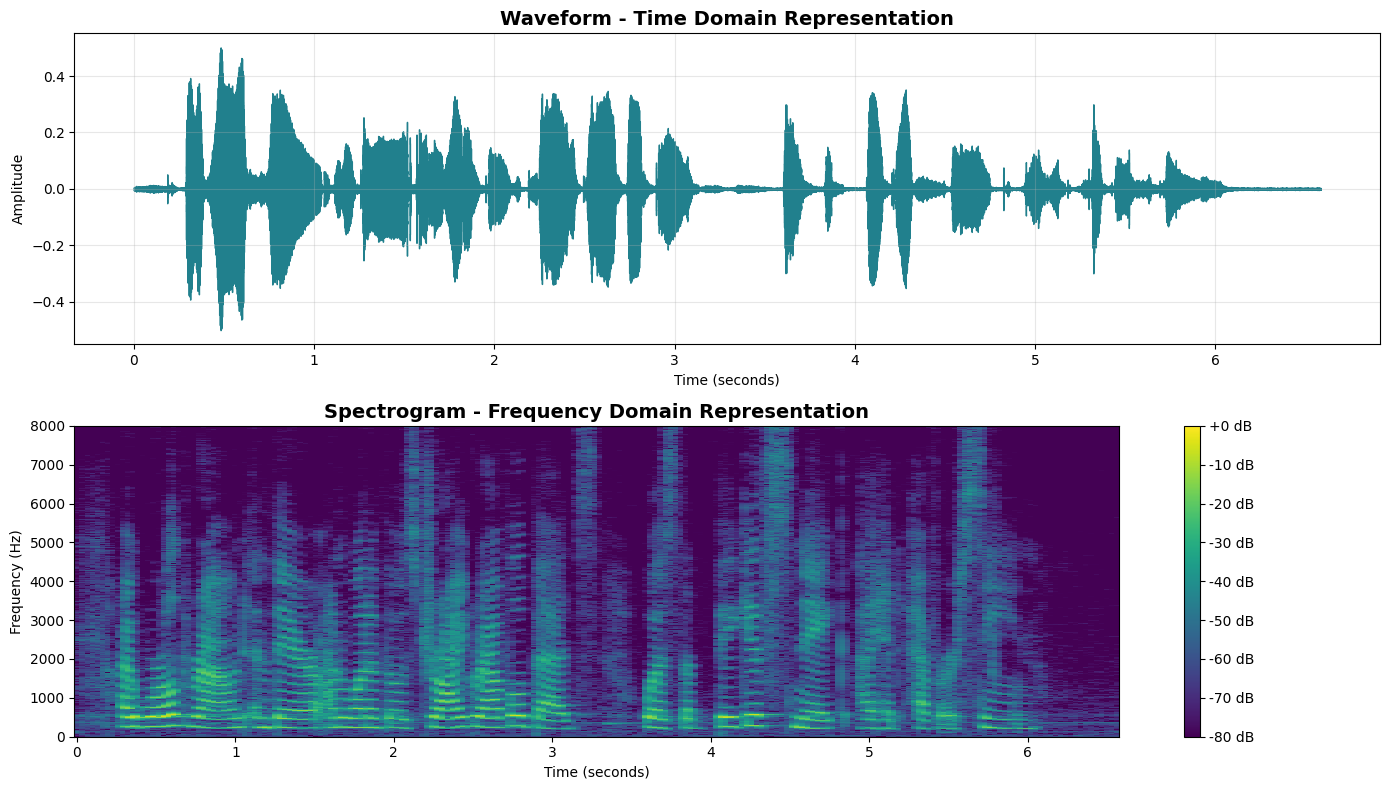


 TASK 1 COMPLETED: Audio Visualization


In [15]:
def load_and_visualize_audio(audio_path, sr=16000):
    """
    Load audio file and create waveform and spectrogram visualizations.

    Args:
        audio_path: Path to audio file
        sr: Sampling rate (16kHz is standard for speech)

    Returns:
        y: Audio time series
        sr: Sampling rate
    """
    print(f" Loading audio: {os.path.basename(audio_path)}")

    # Load audio file
    y, sr = librosa.load(audio_path, sr=sr)
    duration = librosa.get_duration(y=y, sr=sr)

    print(f"Audio loaded successfully!")
    print(f"   Duration: {duration:.2f} seconds")
    print(f"   Sampling Rate: {sr} Hz")
    print(f"   Samples: {len(y)}")

    # Create visualization
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Waveform
    axes[0].set_title('Waveform - Time Domain Representation', fontsize=14, fontweight='bold')
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color='#21808d')
    axes[0].set_xlabel('Time (seconds)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)

    # Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1], cmap='viridis')
    axes[1].set_title('Spectrogram - Frequency Domain Representation', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Time (seconds)')
    axes[1].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

    return y, sr

# Execute Task 1
if AUDIO_FILES:
    # Process first audio file (you can change index to analyze different files)
    sample_audio = AUDIO_FILES[0]
    audio_signal, sample_rate = load_and_visualize_audio(sample_audio)

    print("\n" + "="*60)
    print(" TASK 1 COMPLETED: Audio Visualization")
    print("="*60)
else:
    print(" No audio files available. Please run Task 0 first.")

#Task 2: Acoustic Feature Extraction

Etracting MFCC features...
 MFCC Features Extracted!
   Shape: (13, 206) (coefficients × time frames)
   Mean: -21.576
   Std: 89.026


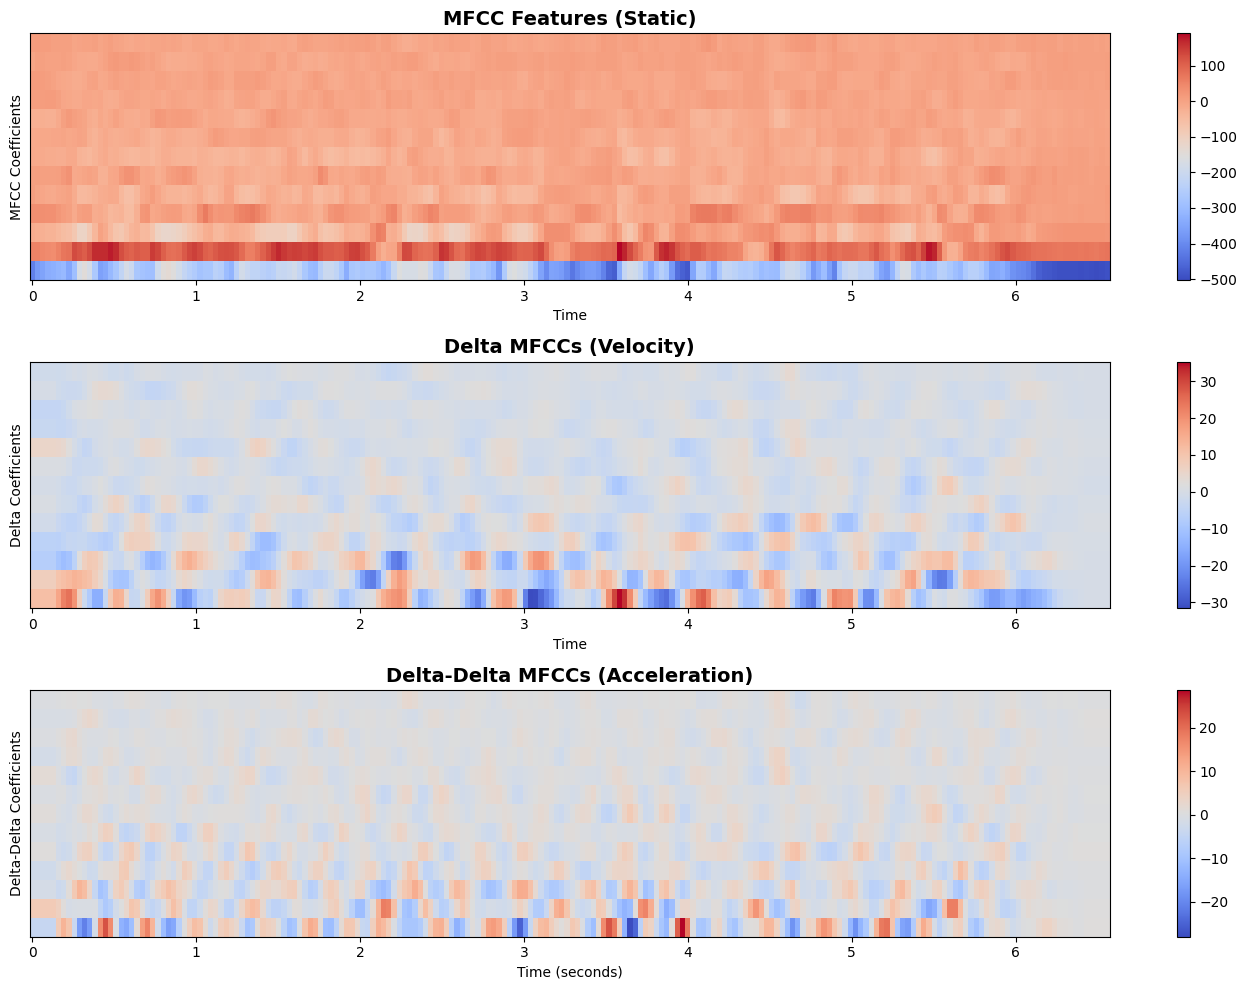


 TASK 2 COMPLETED: MFCC Feature Extraction
   Combined features shape: (39, 206)


In [16]:
def extract_mfcc_features(y, sr, n_mfcc=13, n_fft=2048, hop_length=512):
    """
    Extract MFCC features from audio signal.

    Args:
        y: Audio time series
        sr: Sampling rate
        n_mfcc: Number of MFCCs to extract (13 is standard)
        n_fft: FFT window size
        hop_length: Number of samples between successive frames

    Returns:
        mfccs: MFCC feature matrix
    """
    print("Etracting MFCC features...")

    # Extract MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)

    # Extract delta (velocity) and delta-delta (acceleration) features
    mfcc_delta = librosa.feature.delta(mfccs)
    mfcc_delta2 = librosa.feature.delta(mfccs, order=2)

    print(f" MFCC Features Extracted!")
    print(f"   Shape: {mfccs.shape} (coefficients × time frames)")
    print(f"   Mean: {np.mean(mfccs):.3f}")
    print(f"   Std: {np.std(mfccs):.3f}")

    # Visualize MFCCs
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # MFCCs
    img1 = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[0], cmap='coolwarm')
    axes[0].set_title('MFCC Features (Static)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('MFCC Coefficients')
    fig.colorbar(img1, ax=axes[0])

    # Delta MFCCs
    img2 = librosa.display.specshow(mfcc_delta, sr=sr, x_axis='time', ax=axes[1], cmap='coolwarm')
    axes[1].set_title('Delta MFCCs (Velocity)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Delta Coefficients')
    fig.colorbar(img2, ax=axes[1])

    # Delta-Delta MFCCs
    img3 = librosa.display.specshow(mfcc_delta2, sr=sr, x_axis='time', ax=axes[2], cmap='coolwarm')
    axes[2].set_title('Delta-Delta MFCCs (Acceleration)', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Delta-Delta Coefficients')
    axes[2].set_xlabel('Time (seconds)')
    fig.colorbar(img3, ax=axes[2])

    plt.tight_layout()
    plt.show()

    # Combine all features
    combined_features = np.vstack([mfccs, mfcc_delta, mfcc_delta2])

    return mfccs, combined_features

# Execute Task 2
if 'audio_signal' in globals():
    mfcc_features, combined_features = extract_mfcc_features(audio_signal, sample_rate)

    print("\n" + "="*60)
    print(" TASK 2 COMPLETED: MFCC Feature Extraction")
    print(f"   Combined features shape: {combined_features.shape}")
    print("="*60)
else:
    print("Please run Task 1 first to load audio signal.")

#Task 3: Acoustic Modeling (GMM & HMM)

Training GMM Acoustic Model...
 GMM Model Trained!
   Components: 8
   Log-likelihood: -51.17
   AIC: 21510.57
   BIC: 22226.06

Training HMM Acoustic Model...
 HMM Model Trained!
   States: 5
   Log-likelihood: -10594.07


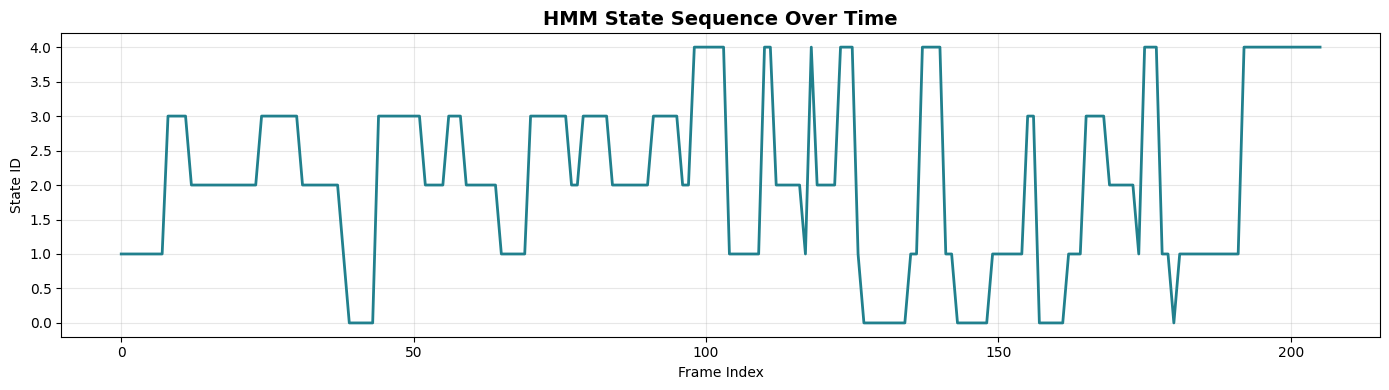


MODEL COMPARISON
GMM Log-Likelihood: -51.17
HMM Log-Likelihood: -10594.07

TASK 3 COMPLETED: Acoustic Modeling


In [17]:
def train_gmm_model(features, n_components=8):
    """
    Train Gaussian Mixture Model on MFCC features.

    Args:
        features: MFCC feature matrix (n_features × n_frames)
        n_components: Number of Gaussian components

    Returns:
        gmm: Trained GMM model
        log_likelihood: Log-likelihood of the data
    """
    print("Training GMM Acoustic Model...")

    # Transpose features for sklearn (n_samples × n_features)
    X = features.T

    # Train GMM
    gmm = GaussianMixture(n_components=n_components, covariance_type='diag',
                          max_iter=100, random_state=42)
    gmm.fit(X)

    # Compute log-likelihood
    log_likelihood = gmm.score(X)

    print(f" GMM Model Trained!")
    print(f"   Components: {n_components}")
    print(f"   Log-likelihood: {log_likelihood:.2f}")
    print(f"   AIC: {gmm.aic(X):.2f}")
    print(f"   BIC: {gmm.bic(X):.2f}")

    return gmm, log_likelihood

def train_hmm_model(features, n_states=5):
    """
    Train Hidden Markov Model on MFCC features.

    Args:
        features: MFCC feature matrix (n_features × n_frames)
        n_states: Number of HMM states

    Returns:
        hmm_model: Trained HMM model
        log_likelihood: Log-likelihood of the data
    """
    print("\nTraining HMM Acoustic Model...")

    # Transpose features for hmmlearn (n_samples × n_features)
    X = features.T
    lengths = [X.shape[0]]  # Single sequence

    # Train HMM with Gaussian emissions
    hmm_model = hmm.GaussianHMM(n_components=n_states, covariance_type="diag",
                                n_iter=100, random_state=42)
    hmm_model.fit(X, lengths)

    # Compute log-likelihood
    log_likelihood = hmm_model.score(X, lengths)

    print(f" HMM Model Trained!")
    print(f"   States: {n_states}")
    print(f"   Log-likelihood: {log_likelihood:.2f}")

    # Predict state sequence
    log_prob, state_sequence = hmm_model.decode(X, lengths)

    # Visualize state sequence
    plt.figure(figsize=(14, 4))
    plt.plot(state_sequence, linewidth=2, color='#21808d')
    plt.title('HMM State Sequence Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Frame Index')
    plt.ylabel('State ID')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return hmm_model, log_likelihood

# Execute Task 3
if 'mfcc_features' in globals():
    # Train GMM
    gmm_model, gmm_ll = train_gmm_model(mfcc_features, n_components=8)

    # Train HMM
    hmm_model, hmm_ll = train_hmm_model(mfcc_features, n_states=5)

    # Compare models
    print("\n" + "="*60)
    print("MODEL COMPARISON")
    print("="*60)
    print(f"GMM Log-Likelihood: {gmm_ll:.2f}")
    print(f"HMM Log-Likelihood: {hmm_ll:.2f}")
    print("\nTASK 3 COMPLETED: Acoustic Modeling")
    print("="*60)
else:
    print(" Please run Task 2 first to extract MFCC features.")

#Task 4: Language Model (Bigram)

In [18]:
import nltk
from collections import defaultdict, Counter
import math

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('brown', quiet=True)

class BigramLanguageModel:
    """
    Bigram Language Model with Laplace smoothing.
    """
    def __init__(self, alpha=1.0):
        """
        Initialize Bigram Language Model.

        Args:
            alpha: Smoothing parameter (1.0 for Laplace smoothing)
        """
        self.alpha = alpha
        self.unigram_counts = Counter()
        self.bigram_counts = defaultdict(Counter)
        self.vocab = set()

    def train(self, corpus):
        """
        Train the bigram model on a corpus.

        Args:
            corpus: List of sentences (each sentence is a list of words)
        """
        print(" Training Bigram Language Model...")

        for sentence in corpus:
            # Add start and end tokens
            tokens = [''] + sentence + ['']

            # Count unigrams
            for token in tokens:
                self.unigram_counts[token] += 1
                self.vocab.add(token)

            # Count bigrams
            for i in range(len(tokens) - 1):
                w1, w2 = tokens[i], tokens[i+1]
                self.bigram_counts[w1][w2] += 1

        self.vocab_size = len(self.vocab)
        print(f" Model trained on {len(corpus)} sentences")
        print(f"   Vocabulary size: {self.vocab_size}")
        print(f"   Total unigrams: {sum(self.unigram_counts.values())}")
        print(f"   Total bigrams: {sum(sum(v.values()) for v in self.bigram_counts.values())}")

    def bigram_probability(self, w1, w2):
        """
        Calculate P(w2|w1) with Laplace smoothing.

        Args:
            w1: Previous word
            w2: Current word

        Returns:
            Probability P(w2|w1)
        """
        numerator = self.bigram_counts[w1][w2] + self.alpha
        denominator = self.unigram_counts[w1] + self.alpha * self.vocab_size
        return numerator / denominator

    def sentence_probability(self, sentence):
        """
        Calculate probability of a sentence.

        Args:
            sentence: List of words

        Returns:
            log_prob: Log probability of sentence
            prob: Probability of sentence
        """
        tokens = [''] + sentence + ['']
        log_prob = 0.0

        for i in range(len(tokens) - 1):
            w1, w2 = tokens[i], tokens[i+1]
            prob = self.bigram_probability(w1, w2)
            log_prob += math.log(prob)

        return log_prob, math.exp(log_prob)

# Prepare training corpus
print(" Preparing training corpus from NLTK Brown corpus...")
from nltk.corpus import brown
corpus = [[word.lower() for word in sent] for sent in brown.sents()[:5000]]

# Train model
lm = BigramLanguageModel(alpha=1.0)
lm.train(corpus)

# Test sentences
test_sentences = [
    "the customer is very satisfied".split(),
    "i want to speak with supervisor".split(),
    "thank you for your help".split(),
    "this is unacceptable service".split(),
    "the the the the the".split()  # Unlikely sentence
]

print("\n" + "="*60)
print(" TESTING LANGUAGE MODEL")
print("="*60)

for sent in test_sentences:
    log_prob, prob = lm.sentence_probability(sent)
    print(f"\nSentence: '{' '.join(sent)}'")
    print(f"  Log Probability: {log_prob:.4f}")
    print(f"  Probability: {prob:.2e}")
    print(f"  Perplexity: {math.exp(-log_prob/len(sent)):.2f}")

print("\n" + "="*60)
print("TASK 4 COMPLETED: Bigram Language Model")
print("="*60)

 Preparing training corpus from NLTK Brown corpus...
 Training Bigram Language Model...
 Model trained on 5000 sentences
   Vocabulary size: 13736
   Total unigrams: 118731
   Total bigrams: 113731

 TESTING LANGUAGE MODEL

Sentence: 'the customer is very satisfied'
  Log Probability: -49.3954
  Probability: 3.53e-22
  Perplexity: 19517.86

Sentence: 'i want to speak with supervisor'
  Log Probability: -59.2624
  Probability: 1.83e-26
  Perplexity: 19478.58

Sentence: 'thank you for your help'
  Log Probability: -56.6973
  Probability: 2.38e-25
  Perplexity: 84074.63

Sentence: 'this is unacceptable service'
  Log Probability: -40.5319
  Probability: 2.50e-18
  Perplexity: 25158.87

Sentence: 'the the the the the'
  Log Probability: -53.0505
  Probability: 9.13e-24
  Perplexity: 40542.57

TASK 4 COMPLETED: Bigram Language Model


#Task 5: Lexicon Integration (CMU Dictionary)

In [19]:
# Lexicon Integration - CMU Pronouncing Dictionary (2 Marks)
import nltk
nltk.download('cmudict', quiet=True)

from nltk.corpus import cmudict

# Load CMU Pronouncing Dictionary
print("📖 Loading CMU Pronouncing Dictionary...")
pronunciation_dict = cmudict.dict()

print(f" Dictionary loaded!")
print(f"   Total words: {len(pronunciation_dict)}")

def get_pronunciation(word):
    """
    Get pronunciation(s) for a word from CMU dictionary.

    Args:
        word: Word to look up

    Returns:
        List of pronunciations (phoneme sequences)
    """
    word_lower = word.lower()
    if word_lower in pronunciation_dict:
        return pronunciation_dict[word_lower]
    else:
        return None

def display_pronunciation(word):
    """
    Display pronunciation details for a word.

    Args:
        word: Word to analyze
    """
    pronunciations = get_pronunciation(word)

    if pronunciations:
        print(f"\n Word: '{word}'")
        print(f"   Found {len(pronunciations)} pronunciation(s):")
        for i, pron in enumerate(pronunciations, 1):
            phonemes = ' '.join(pron)
            print(f"   {i}. {phonemes}")
            print(f"      Phoneme count: {len(pron)}")
    else:
        print(f"\n Word '{word}' not found in dictionary")

# Test call center vocabulary
print("\n" + "="*60)
print(" TESTING PRONUNCIATION LEXICON")
print("="*60)
print("\nCommon Call Center Words:")

test_words = [
    "customer", "service", "complaint", "satisfaction",
    "representative", "supervisor", "telephone", "quality",
    "refund", "technical", "support", "urgent"
]

for word in test_words:
    display_pronunciation(word)

# Analyze phoneme statistics
print("\n" + "="*60)
print(" PHONEME STATISTICS")
print("="*60)

all_phonemes = set()
for pronunciations in pronunciation_dict.values():
    for pron in pronunciations:
        all_phonemes.update(pron)

print(f"Total unique phonemes: {len(all_phonemes)}")
print(f"Phonemes: {sorted(all_phonemes)[:20]}...")

# Stress patterns
def count_syllables(word):
    """Count syllables based on stress markers."""
    pronunciations = get_pronunciation(word)
    if pronunciations:
        # Count stress markers (0, 1, 2) in first pronunciation
        return sum(1 for phoneme in pronunciations[0] if phoneme[-1].isdigit())
    return 0

print("\n📏 Syllable counts for test words:")
for word in test_words[:6]:
    syllables = count_syllables(word)
    print(f"   {word}: {syllables} syllable(s)")

print("\n" + "="*60)
print(" TASK 5 COMPLETED: Lexicon Integration")
print("="*60)

# Summary
print("\n" + "="*60)
print(" ALL TASKS COMPLETED!")
print("="*60)
print("""
Assignment Summary:
✅ Task 1: Speech Data Loading & Visualization (3 Marks)
✅ Task 2: Acoustic Feature Extraction - MFCCs (3 Marks)
✅ Task 3: Acoustic Modeling - GMM & HMM (4 Marks)
✅ Task 4: Language Model - Bigram (3 Marks)
✅ Task 5: Lexicon Integration - CMU Dict (2 Marks)
""")

📖 Loading CMU Pronouncing Dictionary...
 Dictionary loaded!
   Total words: 123455

 TESTING PRONUNCIATION LEXICON

Common Call Center Words:

 Word: 'customer'
   Found 1 pronunciation(s):
   1. K AH1 S T AH0 M ER0
      Phoneme count: 7

 Word: 'service'
   Found 2 pronunciation(s):
   1. S ER1 V AH0 S
      Phoneme count: 5
   2. S ER1 V IH0 S
      Phoneme count: 5

 Word: 'complaint'
   Found 1 pronunciation(s):
   1. K AH0 M P L EY1 N T
      Phoneme count: 8

 Word: 'satisfaction'
   Found 2 pronunciation(s):
   1. S AE2 T AH0 S F AE1 K SH AH0 N
      Phoneme count: 11
   2. S AE2 T IH0 S F AE1 K SH AH0 N
      Phoneme count: 11

 Word: 'representative'
   Found 4 pronunciation(s):
   1. R EH2 P R AH0 Z EH1 N T AH0 T IH0 V
      Phoneme count: 13
   2. R EH2 P R IH0 Z EH1 N T AH0 T IH0 V
      Phoneme count: 13
   3. R EH2 P R AH0 Z EH1 N AH0 T IH0 V
      Phoneme count: 12
   4. R EH2 P R IH0 Z EH1 N AH0 T IH0 V
      Phoneme count: 12

 Word: 'supervisor'
   Found 1 pronunciat